In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# 1. CARGA Y PREPARACIÓN
df = pd.read_csv(r'C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\processed\df_etiquetado_erm400.csv', index_col='datetime', parse_dates=True)
df.head(3)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z
datetime,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,0,Normal,0,0,0.000000,0,Normal / Sin Fallo,1.133893
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,0,Normal,0,0,0.023544,1,Pastilla desgastada (Estanqueidad),1.161931
2023-01-01 00:10:00,16.730278,16.738071,11.562312,16.203283,0.0,42.931357,0.0,698.337504,0,0,64135.745844,13746.320905,0,Normal,0,0,0.030323,1,Pastilla desgastada (Estanqueidad),1.198320


In [7]:
df.tail(4)

,presion_in_A,temperatura_in_A,caudal_bruto_A,caudal_nominal_A,caudal_min_diario_A,caudal_max_diario_A,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z
datetime,,,,,,,,,,,,,,
2023-12-31 23:45:00,16.922499,12.464512,241.308274,4003.663869,0,64135.745844,0,Normal,0,0,0.008387,0,Normal / Sin Fallo,0.927980
2023-12-31 23:50:00,16.914169,10.541830,242.073146,4045.737264,0,64135.745844,0,Normal,0,0,0.008329,0,Normal / Sin Fallo,0.833891
2023-12-31 23:55:00,16.912312,7.747768,242.016055,4090.952330,0,64135.745844,0,Normal,0,0,0.001858,0,Normal / Sin Fallo,0.857241
2024-01-01 00:00:00,16.916201,4.727880,241.338649,4132.091616,0,64135.745844,0,Normal,0,0,0.003889,0,Normal / Sin Fallo,1.016858


In [ ]:
# Configurar para mostrar todas las filas
pd.set_option('display.max_rows', None)
# Configurar para mostrar todas las columnas
pd.set_option('display.max_columns', None)
# Definir variables predictoras (X) - Solo Línea A
features = ['presion_in_A', 'temperatura_in_A',
       'caudal_bruto_A', 'caudal_nominal_A', 'caudal_min_diario_A',
       'caudal_max_diario_A', 'is_anomaly_sap',
       'tipo_fallo_sap_detalle', 'anomaly_IF', 'target_sap_IF',
       'delta_presion_temp', 'is_scada_anomaly', 'tipo_fallo_scada',
       'inestabilidad_z']
df=df[features]
df.head(3)

,presion_in_A,temperatura_in_A,caudal_bruto_A,caudal_nominal_A,caudal_min_diario_A,caudal_max_diario_A,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z
datetime,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,11.613059,0.0,0.0,0,64135.745844,0,Normal,0,0,0.000000,0,Normal / Sin Fallo,1.133893
2023-01-01 00:05:00,16.760601,11.588407,0.0,0.0,0,64135.745844,0,Normal,0,0,0.023544,1,Pastilla desgastada (Estanqueidad),1.161931
2023-01-01 00:10:00,16.730278,11.562312,0.0,0.0,0,64135.745844,0,Normal,0,0,0.030323,1,Pastilla desgastada (Estanqueidad),1.198320


In [ ]:
#df = df.fillna(0) # Limpiar el primer delta_presion que suele ser NaN
# Eliminar la Fila 1, porque tiene el Null en el Delta_presion
#df = df.dropna(subset=['delta_presion_temp'])

In [4]:
df.shape

(105109, 14)

## 1. Verficacion de Valores Faltantes o nulos

In [8]:
# Verficacion de Valores Faltantes o nulos
df.isnull().sum()

presion_in_A              0
temperatura_in_A          0
caudal_bruto_A            0
caudal_nominal_A          0
caudal_min_diario_A       0
caudal_max_diario_A       0
is_anomaly_sap            0
tipo_fallo_sap_detalle    0
anomaly_IF                0
target_sap_IF             0
delta_presion_temp        0
is_scada_anomaly          0
tipo_fallo_scada          0
inestabilidad_z           0
dtype: int64

Código para la Matriz de Correlación (Base + Target):

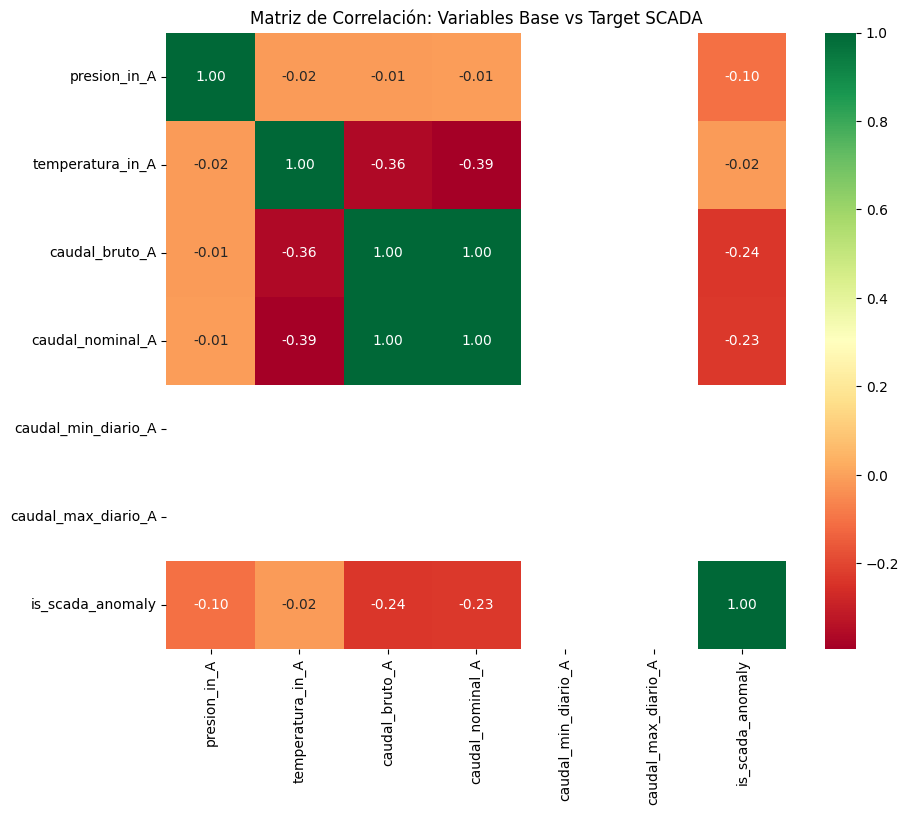

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos variables candidatas + Target
vars_analisis = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 
                 'caudal_nominal_A', 'caudal_min_diario_A', 'caudal_max_diario_A', 
                 'is_scada_anomaly']

corr_matrix = df[vars_analisis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Matriz de Correlación: Variables Base vs Target SCADA")
plt.show()

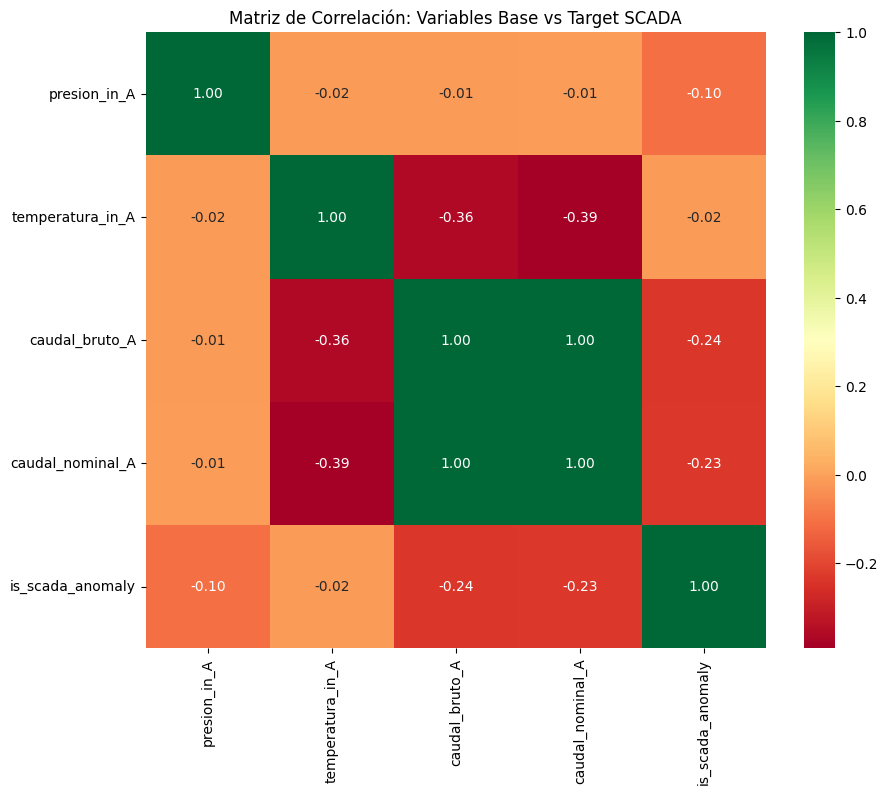

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos variables candidatas + Target
vars_analisis = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 
                 'caudal_nominal_A', 
                 'is_scada_anomaly']

corr_matrix = df[vars_analisis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Matriz de Correlación: Variables Base vs Target SCADA")
plt.show()

## 2. Análisis de Autocorrelación (ACF/PACF)

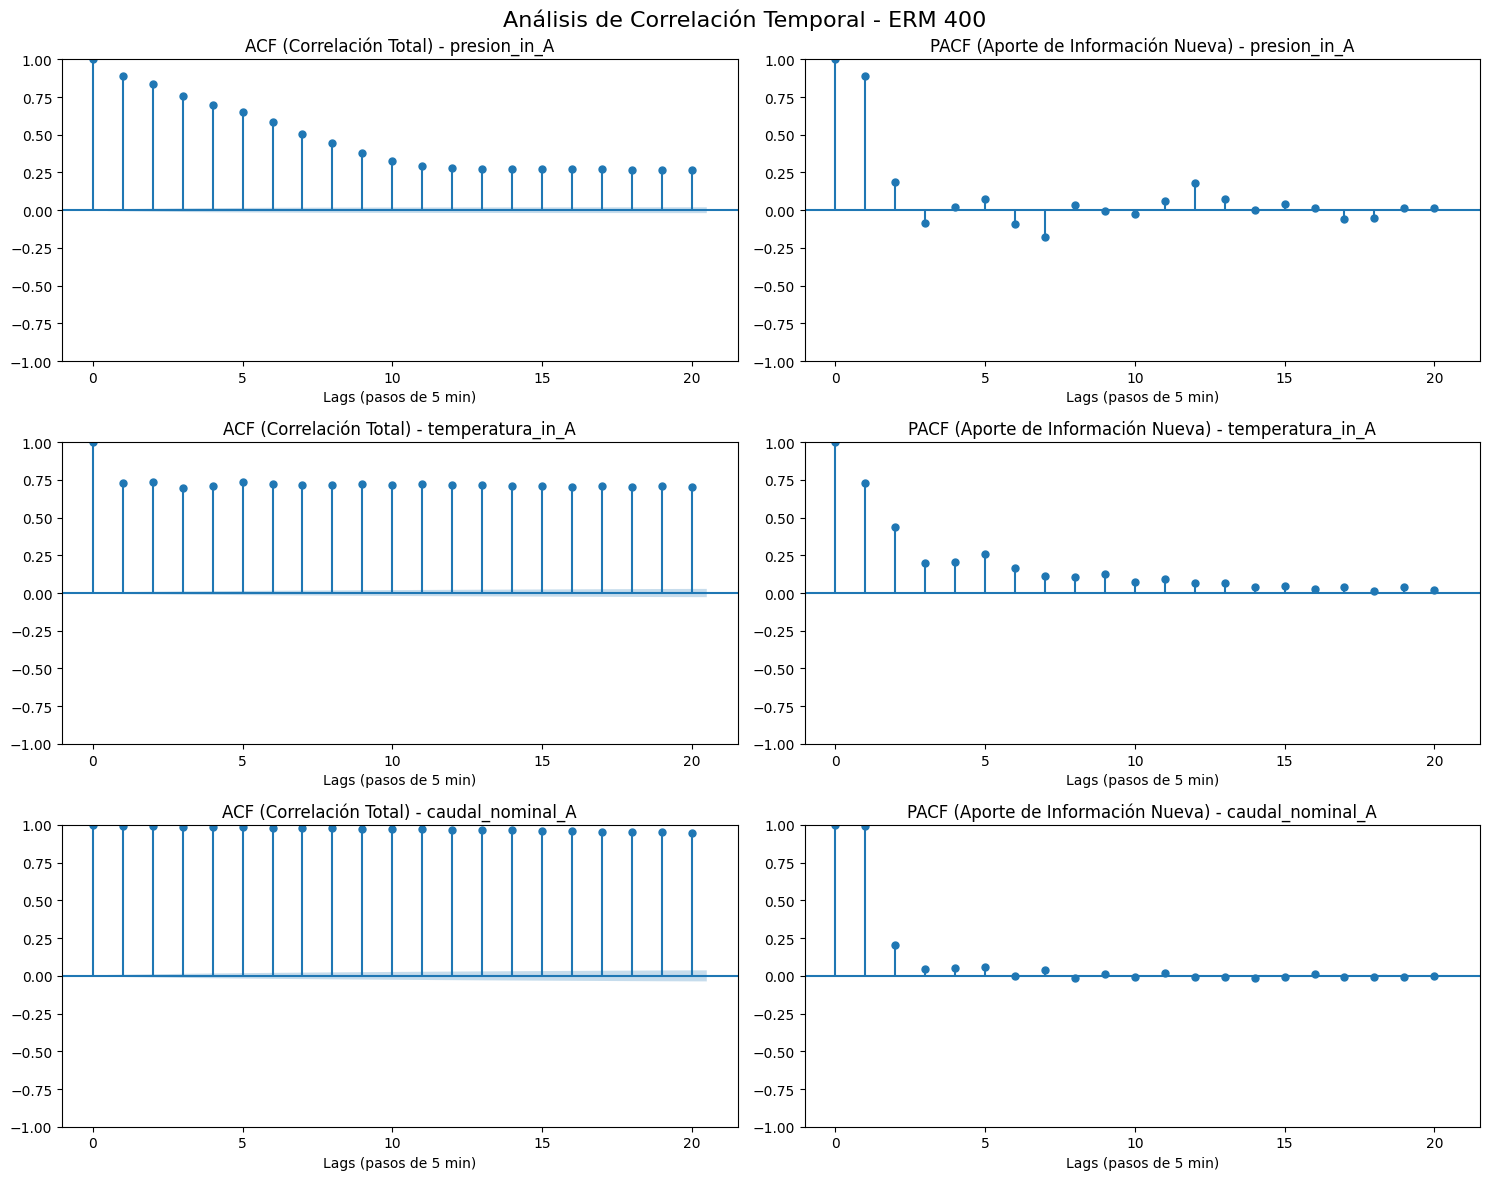

In [11]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# Variables a analizar
variables_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']

# Configuración de la figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
fig.suptitle('Análisis de Correlación Temporal - ERM 400', fontsize=16)

for i, var in enumerate(variables_fisicas):
    # ACF con bandas de confianza claras
    sm.graphics.tsa.plot_acf(df[var], lags=20, ax=axes[i, 0], 
                             alpha=0.05, title=f'ACF (Correlación Total) - {var}')
    
    # PACF con bandas de confianza claras
    sm.graphics.tsa.plot_pacf(df[var], lags=20, ax=axes[i, 1], 
                              alpha=0.05, title=f'PACF (Aporte de Información Nueva) - {var}', 
                              method='ywm')

    # Añadimos etiquetas para que el lector entienda la zona de ruido
    axes[i, 0].set_xlabel('Lags (pasos de 5 min)')
    axes[i, 1].set_xlabel('Lags (pasos de 5 min)')

plt.tight_layout()
plt.show()

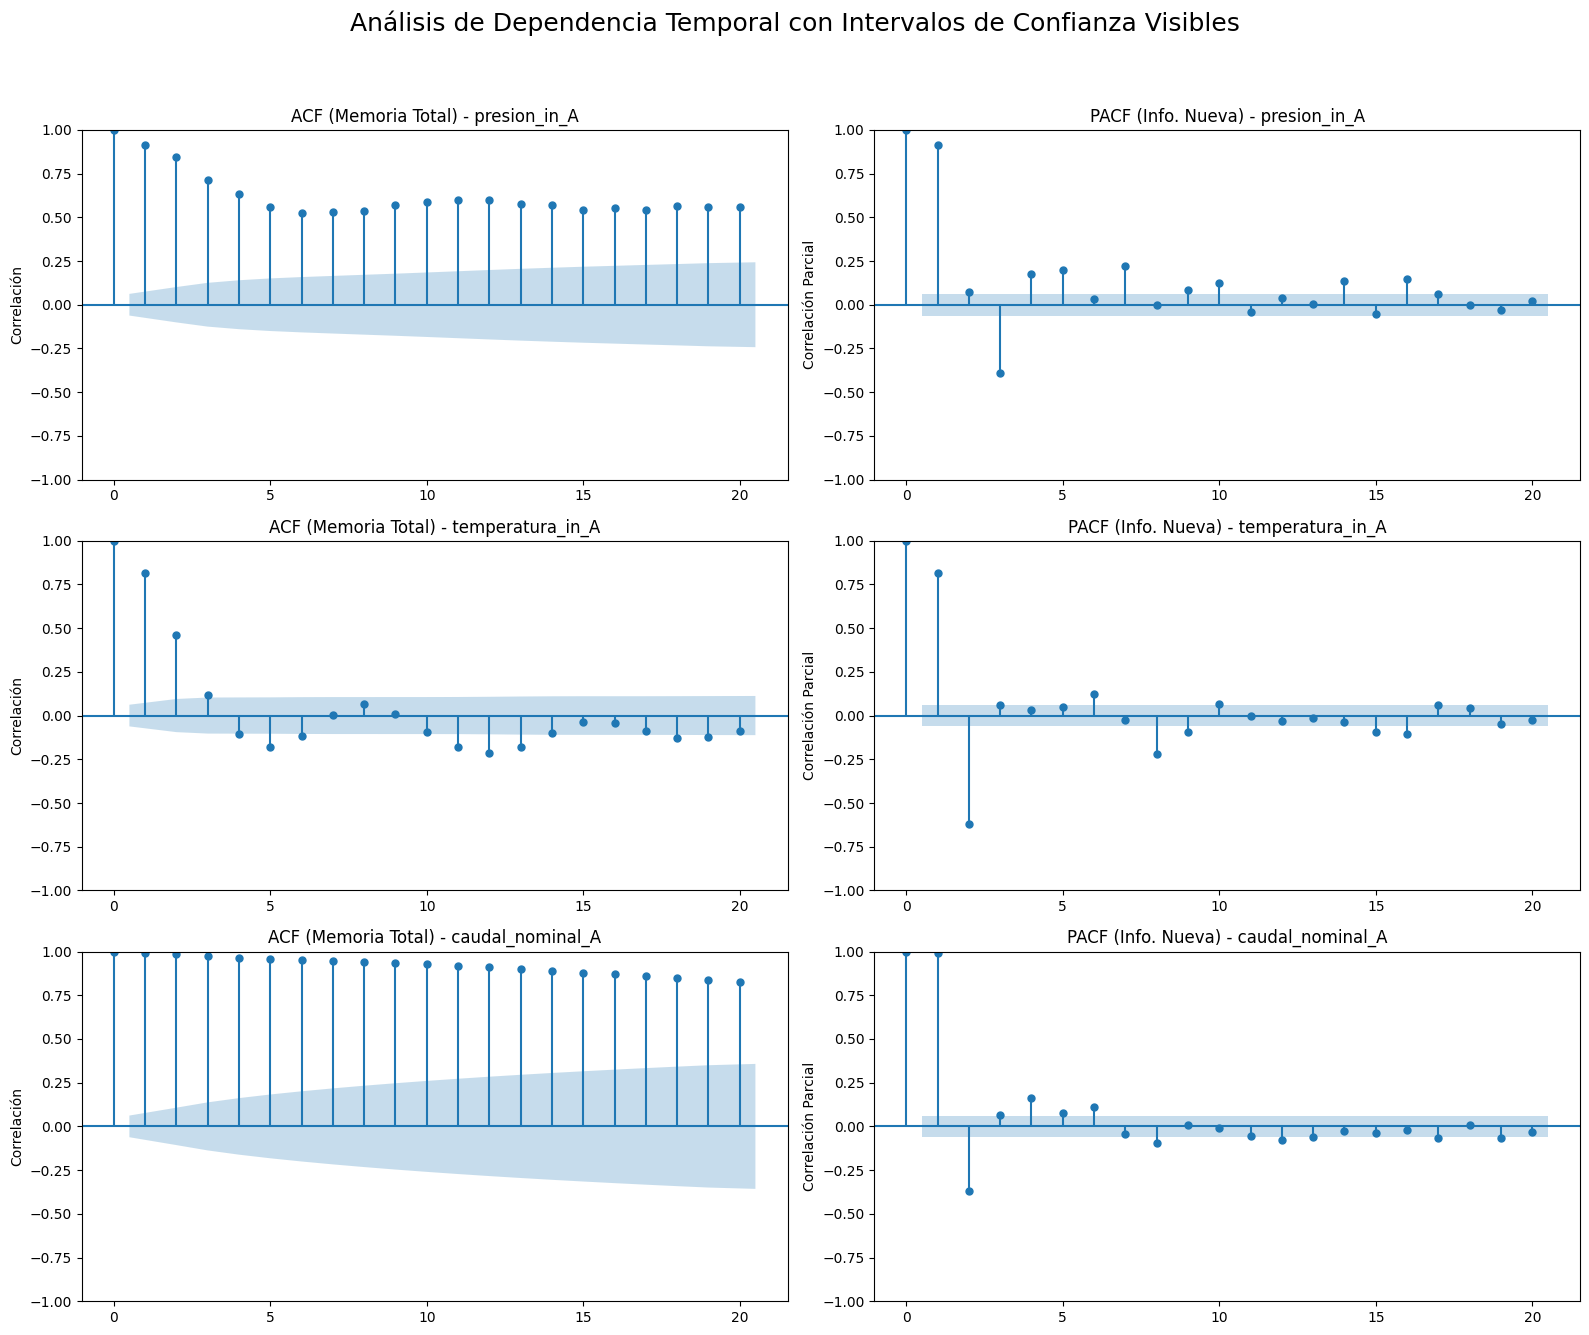

In [6]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Tomamos una muestra para que las bandas sean visibles (ej. 1000 puntos)
# Esto hace que el intervalo de confianza sea ~0.06, perfectamente visible.
df_sample = df.tail(1000) 

variables_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))

for i, var in enumerate(variables_fisicas):
    # Gráfico ACF
    sm.graphics.tsa.plot_acf(df_sample[var], lags=20, ax=axes[i, 0], 
                             alpha=0.05, # Nivel de confianza 95%
                             title=f'ACF (Memoria Total) - {var}')
    
    # Gráfico PACF
    sm.graphics.tsa.plot_pacf(df_sample[var], lags=20, ax=axes[i, 1], 
                              alpha=0.05, 
                              method='ywm',
                              title=f'PACF (Info. Nueva) - {var}')
    
    # Etiquetas de ejes
    axes[i, 0].set_ylabel('Correlación')
    axes[i, 1].set_ylabel('Correlación Parcial')

plt.suptitle('Análisis de Dependencia Temporal con Intervalos de Confianza Visibles', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3. CREACIÓN DE LAGS (SLIDING WINDOW)

In [9]:
# 2. CREACIÓN DE LAGS (SLIDING WINDOW) PERSONALIZADOS
# Definimos cuántos lags queremos para cada variable según el PACF
lags_personalizados = {
    'presion_in_A': 5,
    'temperatura_in_A': 3,
    'caudal_nominal_A': 3
}

df_supervisado = df.copy()

for col, n in lags_personalizados.items():
    for i in range(1, n + 1):
        df_supervisado[f'{col}_lag{i}'] = df_supervisado[col].shift(i)

# Eliminamos los nulos creados por el desplazamiento
df_supervisado = df_supervisado.dropna()

print(f"Lags aplicados: {lags_personalizados}")
print(f"Nuevas dimensiones: {df_supervisado.shape}")

Lags aplicados: {'presion_in_A': 5, 'temperatura_in_A': 3, 'caudal_nominal_A': 3}
Nuevas dimensiones: (105104, 25)


In [10]:
df_supervisado.head(3)

,presion_in_A,temperatura_in_A,caudal_bruto_A,caudal_nominal_A,caudal_min_diario_A,caudal_max_diario_A,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z,presion_in_A_lag1,presion_in_A_lag2,presion_in_A_lag3,presion_in_A_lag4,presion_in_A_lag5,temperatura_in_A_lag1,temperatura_in_A_lag2,temperatura_in_A_lag3,caudal_nominal_A_lag1,caudal_nominal_A_lag2,caudal_nominal_A_lag3
datetime,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:25:00,16.765572,11.530180,0.0,0.0,0,64135.745844,0,Normal,0,0,0.025541,1,Pastilla desgastada (Estanqueidad),1.152885,16.740030,16.720991,16.730278,16.760601,16.784145,11.522590,11.533041,11.562312,0.0,0.0,0.0
2023-01-01 00:30:00,16.787861,11.536973,0.0,0.0,0,64135.745844,0,Normal,0,0,0.022289,1,Pastilla desgastada (Estanqueidad),1.125526,16.765572,16.740030,16.720991,16.730278,16.760601,11.530180,11.522590,11.533041,0.0,0.0,0.0
2023-01-01 00:35:00,16.789719,11.523055,0.0,0.0,0,64135.745844,0,Normal,0,0,0.001858,0,Normal / Sin Fallo,1.122532,16.787861,16.765572,16.740030,16.720991,16.730278,11.536973,11.530180,11.522590,0.0,0.0,0.0


### Seleccion de Variables

Metodo 1: Correlacion

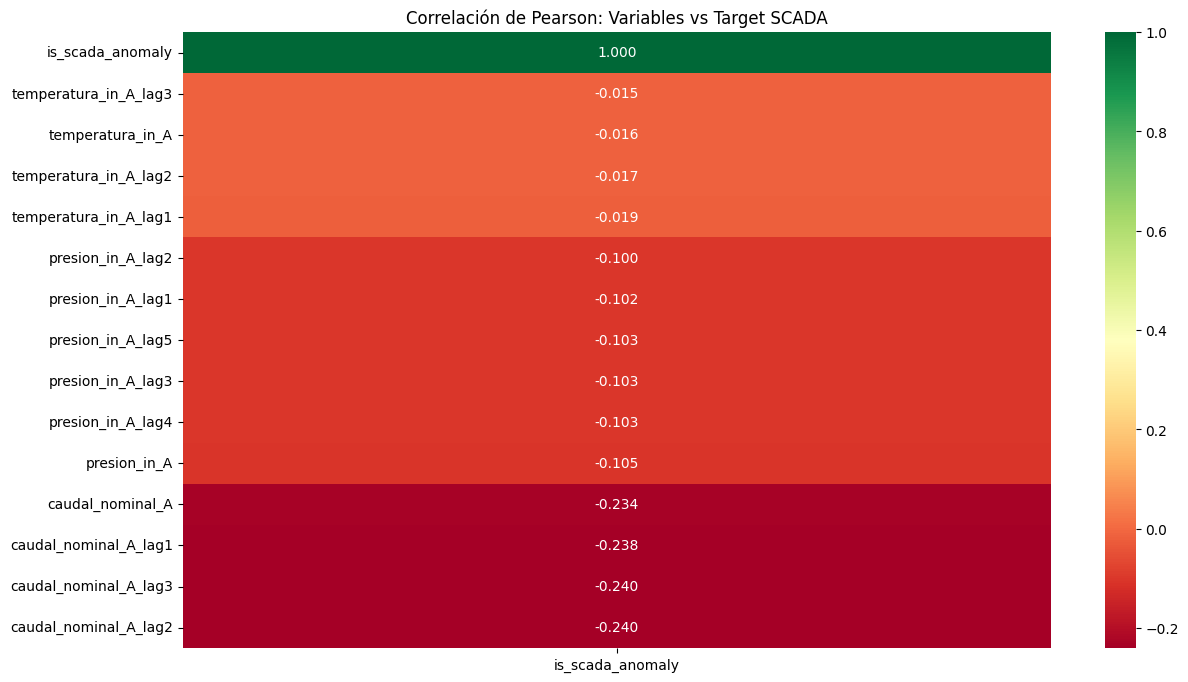

In [11]:
# 1. Matriz de Correlación enfocada en el Target
# ----------------------------------------------------------
# Incluimos variables base y lags para ver la relación temporal
columnas_diagnostico = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A', 'is_scada_anomaly']
lags_existentes = [col for col in df_supervisado.columns if 'lag' in col]
features_diagnostico = columnas_diagnostico + lags_existentes

plt.figure(figsize=(14, 8))
corr_matrix = df_supervisado[features_diagnostico].corr()
# Solo mostramos la correlación con el target para mayor claridad
sns.heatmap(corr_matrix[['is_scada_anomaly']].sort_values(by='is_scada_anomaly', ascending=False), 
            annot=True, cmap='RdYlGn', fmt=".3f")
plt.title("Correlación de Pearson: Variables vs Target SCADA")
plt.show()

Metodo 2: Importancia de Variables con Random Forest (Filtro de Modelo)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. PREPARACIÓN DE VARIABLES ---
columnas_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']
features = columnas_fisicas + [col for col in df_supervisado.columns if 'lag' in col]
X = df_supervisado[features]
y = df_supervisado['is_scada_anomaly'] 

# División única estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. ESCALADO DE DATOS (Vital para SVM y MLP) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled

array([[ 0.50046743,  0.53567085, -0.6872606 , ..., -0.52363341,
        -0.54154241, -0.5652783 ],
       [-0.09083134,  0.70835277,  1.53982433, ...,  1.49877352,
         1.48452644,  1.39663014],
       [-0.18591328, -0.42442287,  1.25206762, ...,  1.20058869,
         1.22169142,  1.22973581],
       ...,
       [ 0.29748941, -0.59099355,  0.04762628, ...,  0.06714456,
        -0.04965713,  0.03287332],
       [ 0.35802576,  1.28900433, -0.43390772, ..., -0.34207605,
        -0.38720858, -0.32717765],
       [ 0.46516966, -0.61758682,  0.63761795, ...,  0.66157091,
         0.68302045,  0.60201379]], shape=(84083, 14))

In [14]:
tuning_rf(X_train_scaled, y_train)

c:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\venv_tfm_enagas\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros RF: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20, 'class_weight': 'balanced'}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

C:\Users\braya\AppData\Local\Temp\ipykernel_21500\3267125380.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


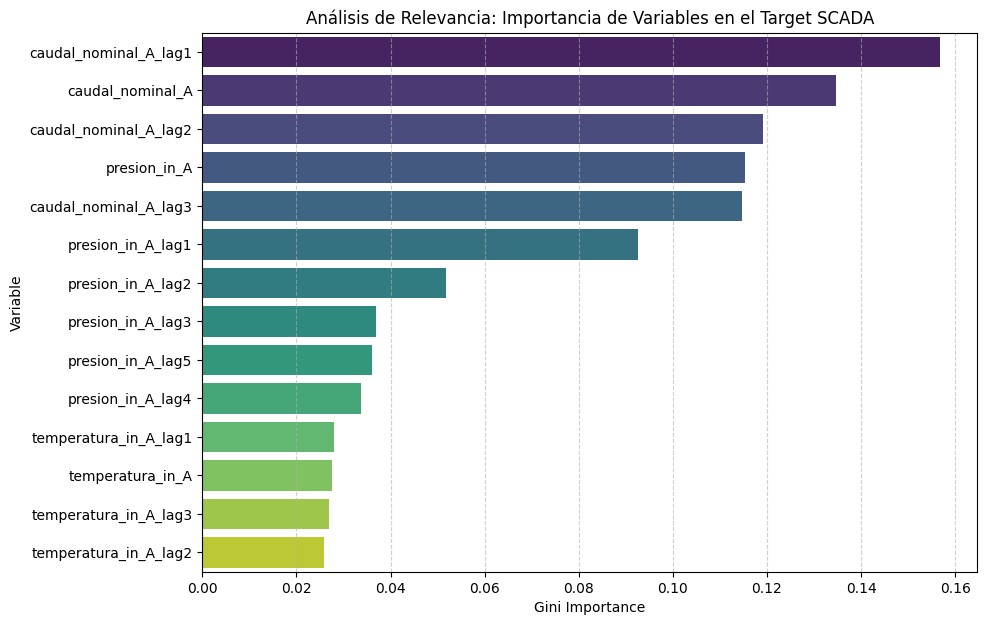

Top 5 Variables Críticas:
                 Variable  Importancia
11  caudal_nominal_A_lag1     0.156852
2        caudal_nominal_A     0.134690
12  caudal_nominal_A_lag2     0.119202
0            presion_in_A     0.115266
13  caudal_nominal_A_lag3     0.114744
3       presion_in_A_lag1     0.092541
4       presion_in_A_lag2     0.051797
5       presion_in_A_lag3     0.036923
7       presion_in_A_lag5     0.036008
6       presion_in_A_lag4     0.033730
8   temperatura_in_A_lag1     0.027973
1        temperatura_in_A     0.027501
10  temperatura_in_A_lag3     0.027010
9   temperatura_in_A_lag2     0.025763


In [ ]:
# --- 3. DIAGNÓSTICO INDEPENDIENTE DE RELEVANCIA (Feature Importance) ---
# Usamos el X_train original (sin escalar) para que las etiquetas de las gráficas 
# sean legibles, ya que RF no requiere escalado.
selector_diagnostico = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20,
    min_samples_split=5,
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)
selector_diagnostico.fit(X_train_scaled, y_train)

# Extracción de resultados
df_importancia = pd.DataFrame({
    'Variable': features,
    'Importancia': selector_diagnostico.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# --- 4. VISUALIZACIÓN DE RESULTADOS ---
plt.figure(figsize=(10, 7))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title("Análisis de Relevancia: Importancia de Variables en el Target SCADA")
plt.xlabel("Gini Importance")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Imprimir el top 5 para tu análisis en el texto del TFM
print("Top Variables Críticas:")
print(df_importancia)

## 4. Modelos de ML

In [ ]:
# 3. PREPARACIÓN DE VARIABLES PARA RANDOM FOREST 
# Definimos cuáles son nuestras bases físicas
columnas_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']

# Recolectamos dinámicamente las columnas originales + los lags recién creados
features = columnas_fisicas + [col for col in df_supervisado.columns if 'lag' in col]
X = df_supervisado[features]

# Definimos el target físico (SCADA)
y = df_supervisado['is_scada_anomaly']

# División única para que todos compitan bajo las mismas condiciones
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
X.head(3)

,presion_in_A,temperatura_in_A,caudal_nominal_A,presion_in_A_lag1,presion_in_A_lag2,presion_in_A_lag3,presion_in_A_lag4,presion_in_A_lag5,temperatura_in_A_lag1,temperatura_in_A_lag2,temperatura_in_A_lag3,caudal_nominal_A_lag1,caudal_nominal_A_lag2,caudal_nominal_A_lag3
datetime,,,,,,,,,,,,,,
2023-01-01 00:25:00,16.765572,11.530180,0.0,16.740030,16.720991,16.730278,16.760601,16.784145,11.522590,11.533041,11.562312,0.0,0.0,0.0
2023-01-01 00:30:00,16.787861,11.536973,0.0,16.765572,16.740030,16.720991,16.730278,16.760601,11.530180,11.522590,11.533041,0.0,0.0,0.0
2023-01-01 00:35:00,16.789719,11.523055,0.0,16.787861,16.765572,16.740030,16.720991,16.730278,11.536973,11.530180,11.522590,0.0,0.0,0.0


In [17]:
y.head(3)

datetime
2023-01-01 00:25:00    1
2023-01-01 00:30:00    1
2023-01-01 00:35:00    0
Name: is_scada_anomaly, dtype: int64

## 5. Entrenamiento de Modelos 

### A. Tuning: Random Forest

In [13]:
from sklearn.model_selection import RandomizedSearchCV

# --- A. Tuning: Random Forest (Optimizado) ---
def tuning_rf(X_train, y_train):
    param_dist = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, 20],
        'min_samples_split': [2, 5],
        'class_weight': ['balanced']
    }
    # n_iter=10 significa que solo probará 10 combinaciones aleatorias
    search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42), 
        param_distributions=param_dist, 
        n_iter=10, cv=3, scoring='f1', n_jobs=2, random_state=42
    )
    search.fit(X_train, y_train)
    print(f"Mejores parámetros RF: {search.best_params_}")
    return search.best_estimator_

In [ ]:
tuning_rf(X_train_scaled, y_train)

c:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\venv_tfm_enagas\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros RF: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20, 'class_weight': 'balanced'}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

def entrenar_rf(X_train, X_test, y_train, y_test, titulo):
    """
    Entrena un Random Forest usando los sets ya divididos.
    """
    # Usamos class_weight='balanced' para compensar que hay pocos síntomas vs datos normales
    model = RandomForestClassifier(n_estimators=100, 
                                    max_depth=20,
                                    min_samples_split=5,
                                    random_state=42,
                                    class_weight='balanced')
    
    # 2. Configuramos el K-Fold (Stratified es ideal para clases desbalanceadas)
    kfold_validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. Ejecutamos la Validación Cruzada (¡SOLO en X_train!)
    # Usamos scoring='f1' porque es mejor que accuracy para detectar fallos
    resultados_cv = cross_val_score(model, X_train, y_train, cv=kfold_validacion, scoring='f1')
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*40}")
    print(f"--- PERFORMANCE: {titulo} ---")
    print(f"{'='*40}")
    
    print(">> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<")
    print(f"Puntuaciones (F1) de cada fold: {np.round(resultados_cv, 4)}")
    print(f"Promedio F1-Score: {resultados_cv.mean():.4f}\n")
    
    print(">> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<")
    print(classification_report(y_test, y_pred))
    
    return model, y_pred

### B. Tuning: XGBoost

In [19]:
from xgboost import XGBClassifier

def tuning_xgboost(X_train, y_train):
    ratio = (len(y_train) - sum(y_train)) / sum(y_train)
    param_dist = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 6],
        'subsample': [0.8]
    }
    search = RandomizedSearchCV(
        XGBClassifier(random_state=42, scale_pos_weight=ratio), 
        param_distributions=param_dist, 
        n_iter=8, cv=3, scoring='f1', n_jobs=2, random_state=42
    )
    search.fit(X_train, y_train)
    print(f"Mejores parámetros XGB: {search.best_params_}")
    return search.best_estimator_

In [23]:
tuning_xgboost(X_train_scaled, y_train)

Mejores parámetros XGB: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
from xgboost import XGBClassifier

def entrenar_xgboost(X_train, X_test, y_train, y_test):
    # Calculamos el peso para balancear la clase minoritaria
    ratio = (len(y_train) - sum(y_train)) / sum(y_train)
    
    model = XGBClassifier(n_estimators=200,
                          learning_rate=0.1,
                          max_depth=6,
                          subsample=0.8,
                          #scale_pos_weight=1,# Cuando no se usa balanced
                           random_state=42,
                            scale_pos_weight=ratio)
    
    # 2. Configuramos el K-Fold (Stratified es ideal para clases desbalanceadas)
    kfold_validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. Ejecutamos la Validación Cruzada (¡SOLO en X_train!)
    # Usamos scoring='f1' porque es mejor que accuracy para detectar fallos
    resultados_cv = cross_val_score(model, X_train, y_train, cv=kfold_validacion, scoring='f1')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: XGBOOST ---")

    print(">> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<")
    print(f"Puntuaciones (F1) de cada fold: {np.round(resultados_cv, 4)}")
    print(f"Promedio F1-Score: {resultados_cv.mean():.4f}\n")

    print(">> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<")
    print(classification_report(y_test, y_pred))
    return model, y_pred

### C. Tuning: Linear SVM

In [25]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def tuning_svm(X_train, y_train):
    param_dist = {
        'C': [0.1, 1, 10],
        'loss': ['squared_hinge'],
        'max_iter': [1500, 2000]
    }
    search = RandomizedSearchCV(
        LinearSVC(random_state=42, dual=False, class_weight='balanced'), 
        param_distributions=param_dist, 
        n_iter=5, cv=3, scoring='f1', n_jobs=2, random_state=42
    )
    search.fit(X_train, y_train)
    print(f"Mejores parámetros SVM: {search.best_params_}")
    return CalibratedClassifierCV(search.best_estimator_)

In [28]:
tuning_svm(X_train_scaled, y_train)

Mejores parámetros SVM: {'max_iter': 1500, 'loss': 'squared_hinge', 'C': 1}


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=1...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" 

In [14]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def entrenar_svm(X_train, X_test, y_train, y_test):
    # 1. Definimos el modelo lineal rápido
    # 'dual=False' se recomienda cuando el número de muestras es mayor al de variables
    base_svc = LinearSVC(C=1,
                         loss='squared_hinge',
                         random_state=42, 
                         max_iter=1500, 
                         dual=False,
                        class_weight='balanced') 
    
    # 2. Configuramos el K-Fold (Stratified es ideal para clases desbalanceadas)
    kfold_validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. Ejecutamos la Validación Cruzada (¡SOLO en X_train!)
    # Usamos scoring='f1' porque es mejor que accuracy para detectar fallos
    resultados_cv = cross_val_score(base_svc, X_train, y_train, cv=kfold_validacion, scoring='f1')

    # Calibración y Entrenamiento Final
    # Lo envolvemos para obtener probabilidades (predict_proba)
    model = CalibratedClassifierCV(base_svc)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: LINEAR SVM (Optimizado) ---")
    
    print(">> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<")
    print(f"Puntuaciones (F1) de cada fold: {np.round(resultados_cv, 4)}")
    print(f"Promedio F1-Score: {resultados_cv.mean():.4f}\n")

    print(">> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<")
    print(classification_report(y_test, y_pred))
    return model, y_pred

### D. Tuning: MLP (Red Neuronal)

In [30]:
from sklearn.neural_network import MLPClassifier

def tuning_mlp(X_train, y_train):
    param_dist = {
        'hidden_layer_sizes': [(64, 32), (128, 64), (64,)],
        'alpha': [0.001, 0.01],
        'learning_rate_init': [0.001, 0.01],
        'max_iter': [300, 600, 1000]
    }
    search = RandomizedSearchCV(
        MLPClassifier(random_state=42), 
        param_distributions=param_dist, 
        n_iter=5, cv=3, scoring='f1', n_jobs=2, random_state=42
    )
    search.fit(X_train, y_train)
    print(f"Mejores parámetros MLP: {search.best_params_}")
    return search.best_estimator_

In [31]:
tuning_mlp(X_train_scaled, y_train)

Mejores parámetros MLP: {'max_iter': 600, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64,), 'alpha': 0.001}


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",600
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [15]:
from sklearn.neural_network import MLPClassifier

def entrenar_mlp_nn(X_train, X_test, y_train, y_test):
    # Arquitectura de 2 capas ocultas
    model = MLPClassifier(hidden_layer_sizes=(64,), 
                          alpha=0.001,
                          learning_rate_init=0.001,
                          activation='relu', 
                          max_iter=500, 
                          random_state=42)
    
    # 2. Configuramos el K-Fold (Stratified es ideal para clases desbalanceadas)
    kfold_validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. Ejecutamos la Validación Cruzada (¡SOLO en X_train!)
    # Usamos scoring='f1' porque es mejor que accuracy para detectar fallos
    resultados_cv = cross_val_score(model, X_train, y_train, cv=kfold_validacion, scoring='f1')
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: MULTI-LAYER PERCEPTRON (NN) ---")
    
    print(">> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<")
    print(f"Puntuaciones (F1) de cada fold: {np.round(resultados_cv, 4)}")
    print(f"Promedio F1-Score: {resultados_cv.mean():.4f}\n")

    print(">> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<")
    print(classification_report(y_test, y_pred))
    return model, y_pred

**PARTE 1: Comparativa SAP vs. SCADA**

Aquí usamos el mismo modelo (Random Forest) para exponer la diferencia de calidad entre los datos de gestión y los físicos.

In [12]:
df_supervisado.columns

Index(['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A',
       'caudal_nominal_A', 'caudal_min_diario_A', 'caudal_max_diario_A',
       'is_anomaly_sap', 'tipo_fallo_sap_detalle', 'anomaly_IF',
       'target_sap_IF', 'delta_presion_temp', 'is_scada_anomaly',
       'tipo_fallo_scada', 'inestabilidad_z', 'presion_in_A_lag1',
       'presion_in_A_lag2', 'presion_in_A_lag3', 'presion_in_A_lag4',
       'presion_in_A_lag5', 'temperatura_in_A_lag1', 'temperatura_in_A_lag2',
       'temperatura_in_A_lag3', 'caudal_nominal_A_lag1',
       'caudal_nominal_A_lag2', 'caudal_nominal_A_lag3'],
      dtype='str')


--- PERFORMANCE: SÍNTOMAS SAP (Gestión) ---
>> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<
Puntuaciones (F1) de cada fold: [0.2609 0.3815 0.3158 0.3584 0.2771]
Promedio F1-Score: 0.3187

>> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     20848
           1       0.96      0.28      0.43       173

    accuracy                           0.99     21021
   macro avg       0.98      0.64      0.71     21021
weighted avg       0.99      0.99      0.99     21021


--- PERFORMANCE: SÍNTOMAS SCADA (Física) ---
>> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<
Puntuaciones (F1) de cada fold: [0.5965 0.588  0.6204 0.5947 0.5995]
Promedio F1-Score: 0.5998

>> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     19390
           1       0.80      0.50      0.62      1631

    accuracy

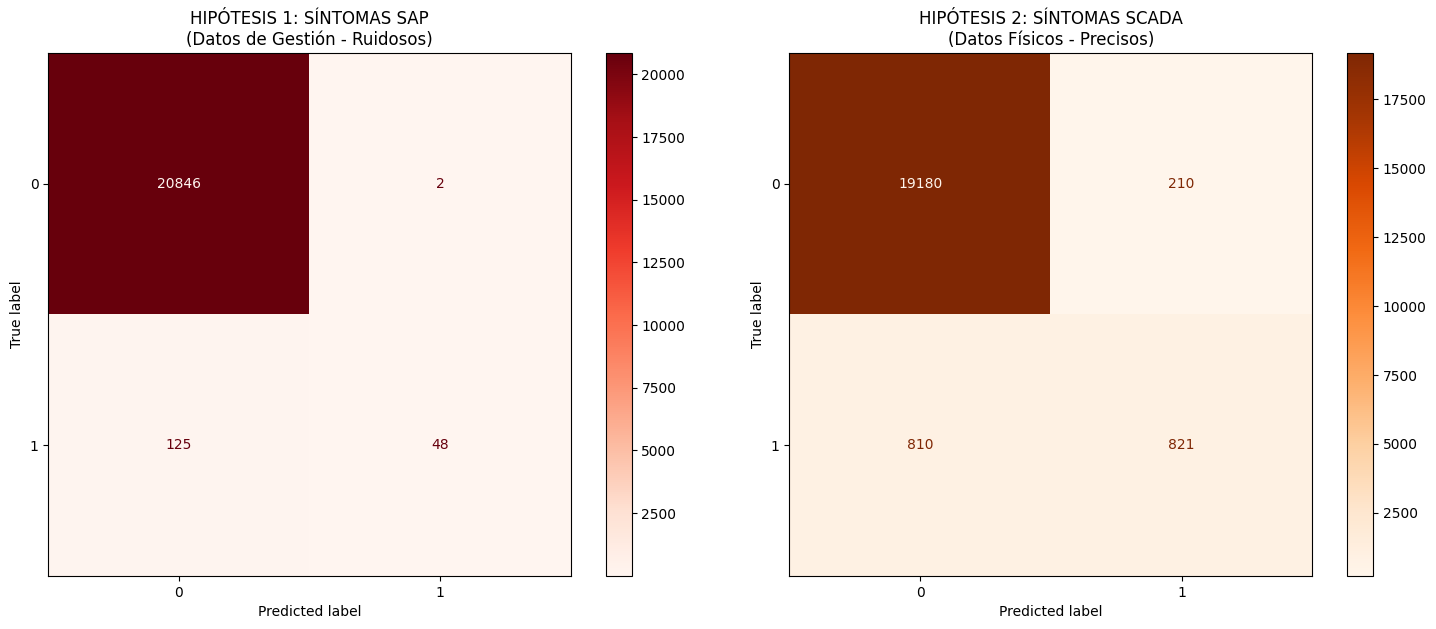

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

# --- A. Entrenar para SAP ---
y_sap = df_supervisado['is_anomaly_sap']
X_train_sap, X_test_sap, y_train_sap, y_test_sap = train_test_split(X, y_sap, test_size=0.2, random_state=42, stratify=y_sap)
model_sap, pred_sap = entrenar_rf(X_train_sap, X_test_sap, y_train_sap, y_test_sap, "SÍNTOMAS SAP (Gestión)")

# --- B. Entrenar para SCADA ---
y_scada = df_supervisado['is_scada_anomaly']
X_train_scada, X_test_scada, y_train_scada, y_test_scada = train_test_split(X, y_scada, test_size=0.2, random_state=42, stratify=y_scada)
model_scada, pred_scada = entrenar_rf(X_train_scada, X_test_scada, y_train_scada, y_test_scada, "SÍNTOMAS SCADA (Física)")

# --- C. Visualización Comparativa de Hipótesis ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions(y_test_sap, pred_sap, ax=ax[0], cmap='Reds')
ax[0].set_title('HIPÓTESIS 1: SÍNTOMAS SAP\n(Datos de Gestión - Ruidosos)')

ConfusionMatrixDisplay.from_predictions(y_test_scada, pred_scada, ax=ax[1], cmap='Oranges')
ax[1].set_title('HIPÓTESIS 2: SÍNTOMAS SCADA\n(Datos Físicos - Precisos)')

plt.tight_layout()
plt.show()

In [35]:
X_train_scaled

array([[ 0.50046743,  0.53567085, -0.6872606 , ..., -0.52363341,
        -0.54154241, -0.5652783 ],
       [-0.09083134,  0.70835277,  1.53982433, ...,  1.49877352,
         1.48452644,  1.39663014],
       [-0.18591328, -0.42442287,  1.25206762, ...,  1.20058869,
         1.22169142,  1.22973581],
       ...,
       [ 0.29748941, -0.59099355,  0.04762628, ...,  0.06714456,
        -0.04965713,  0.03287332],
       [ 0.35802576,  1.28900433, -0.43390772, ..., -0.34207605,
        -0.38720858, -0.32717765],
       [ 0.46516966, -0.61758682,  0.63761795, ...,  0.66157091,
         0.68302045,  0.60201379]], shape=(84083, 14))

**PARTE 2: Competencia de Modelos (Selección de la Herramienta)**

Ahora que los resultados de arriba te dirán que "SCADA es el camino", procedes a optimizar la detección física con los otros modelos que creamos.

In [16]:
df_supervisado.head(3)

,presion_in_A,temperatura_in_A,caudal_bruto_A,caudal_nominal_A,caudal_min_diario_A,caudal_max_diario_A,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z,presion_in_A_lag1,presion_in_A_lag2,presion_in_A_lag3,presion_in_A_lag4,presion_in_A_lag5,temperatura_in_A_lag1,temperatura_in_A_lag2,temperatura_in_A_lag3,caudal_nominal_A_lag1,caudal_nominal_A_lag2,caudal_nominal_A_lag3
datetime,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:25:00,16.765572,11.530180,0.0,0.0,0,64135.745844,0,Normal,0,0,0.025541,1,Pastilla desgastada (Estanqueidad),1.152885,16.740030,16.720991,16.730278,16.760601,16.784145,11.522590,11.533041,11.562312,0.0,0.0,0.0
2023-01-01 00:30:00,16.787861,11.536973,0.0,0.0,0,64135.745844,0,Normal,0,0,0.022289,1,Pastilla desgastada (Estanqueidad),1.125526,16.765572,16.740030,16.720991,16.730278,16.760601,11.530180,11.522590,11.533041,0.0,0.0,0.0
2023-01-01 00:35:00,16.789719,11.523055,0.0,0.0,0,64135.745844,0,Normal,0,0,0.001858,0,Normal / Sin Fallo,1.122532,16.787861,16.765572,16.740030,16.720991,16.730278,11.536973,11.530180,11.522590,0.0,0.0,0.0


In [17]:
df_supervisado.shape

(105104, 25)

In [18]:
from sklearn.preprocessing import StandardScaler

# 3. PREPARACIÓN DE VARIABLES
#columnas_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']

## Eleccion de variables a usar en los Modelos
#features = columnas_fisicas + [col for col in df_supervisado.columns if 'lag' in col]


#  Definir solo el Top según Feature Importance ---
features_top = [
    'caudal_nominal_A_lag1', 
    'caudal_nominal_A', 
    'caudal_nominal_A_lag2',
    'presion_in_A', 
    'caudal_nominal_A_lag3',
    'presion_in_A_lag1'
]

#X_top = df_supervisado[features_top]
X = df_supervisado[features_top]

y = df_supervisado['is_scada_anomaly'] 

# División única estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- ESCALADO DE DATOS (Vital para SVM y MLP) ---
# Creamos el escalador y lo ajustamos SOLO con el X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*50)
print("INICIO DE COMPETENCIA DE MODELOS (TARGET: SCADA)")
print("="*50)

# Random Forest y XGBoost pueden usar los datos escalados sin problemas
model_rf, pred_rf = entrenar_rf(X_train_scaled, X_test_scaled, y_train, y_test, "RANDOM FOREST")
model_xgb, pred_xgb = entrenar_xgboost(X_train_scaled, X_test_scaled, y_train, y_test)

# SVM y MLP REQUIEREN obligatoriamente X_train_scaled y X_test_scaled
model_svm, pred_svm = entrenar_svm(X_train_scaled, X_test_scaled, y_train, y_test)
model_nn, pred_nn = entrenar_mlp_nn(X_train_scaled, X_test_scaled, y_train, y_test)


INICIO DE COMPETENCIA DE MODELOS (TARGET: SCADA)

--- PERFORMANCE: RANDOM FOREST ---
>> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<
Puntuaciones (F1) de cada fold: [0.7517 0.7255 0.7722 0.7295 0.7225]
Promedio F1-Score: 0.7403

>> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     19390
           1       0.75      0.73      0.74      1631

    accuracy                           0.96     21021
   macro avg       0.86      0.85      0.86     21021
weighted avg       0.96      0.96      0.96     21021


--- PERFORMANCE: XGBOOST ---
>> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<
Puntuaciones (F1) de cada fold: [0.8064 0.7989 0.8065 0.8046 0.8112]
Promedio F1-Score: 0.8055

>> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     19390
           1       0.68      0.98      0.8

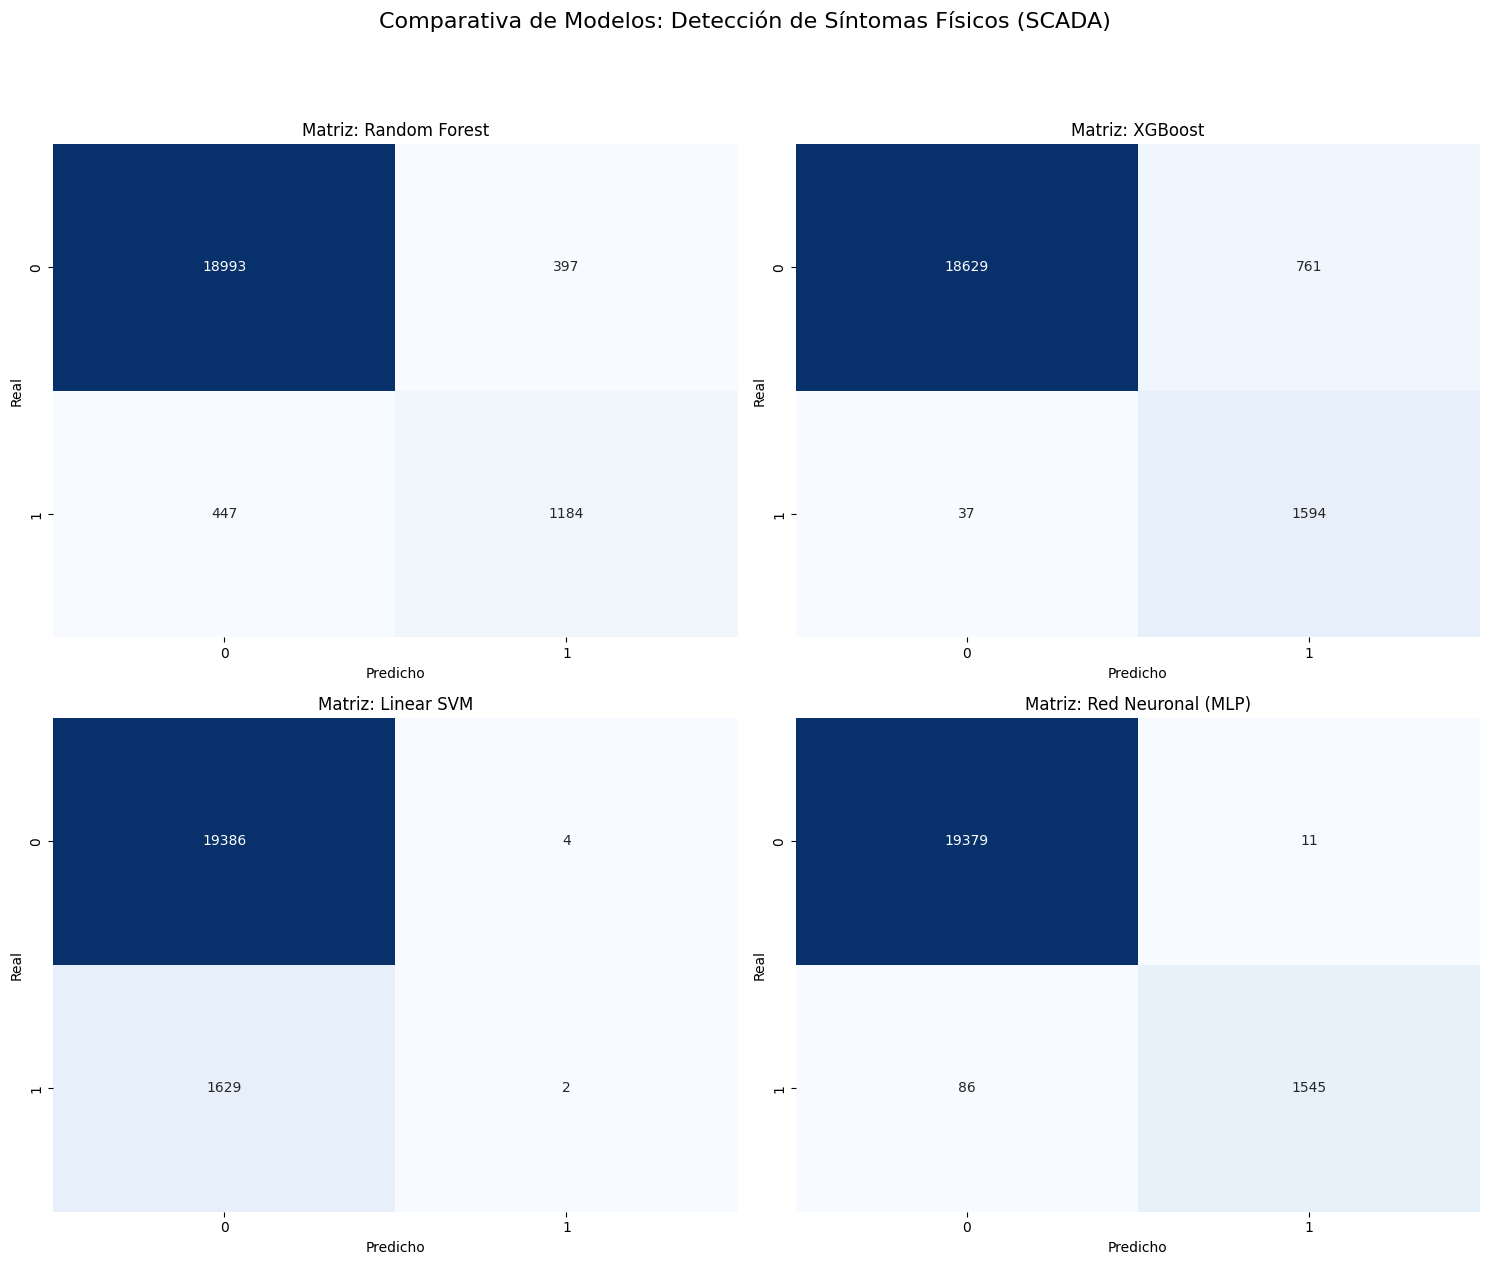

In [19]:
# --- Visualización de la Competencia ---
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Definición de la Función
def plot_confusion_en_eje(y_real, y_pred, titulo, ax_obj):
    """
    Dibuja la matriz de confusión en un eje específico del subplot.
    """
    cm = confusion_matrix(y_real, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_obj, cbar=False)
    ax_obj.set_title(f'Matriz: {titulo}')
    ax_obj.set_ylabel('Real')
    ax_obj.set_xlabel('Predicho')

# 2. Visualización de la Competencia
# --- Visualización de la Competencia (Target: SCADA) ---
fig, ax = plt.subplots(2, 2, figsize=(15, 12)) # Cambiado a 4 columnas

# APLANAMOS el array para acceder como ax_flat[0], [1], [2], [3]
ax_flat = ax.flatten()

plot_confusion_en_eje(y_test, pred_rf, "Random Forest", ax_flat[0])
plot_confusion_en_eje(y_test, pred_xgb, "XGBoost", ax_flat[1])
plot_confusion_en_eje(y_test, pred_svm, "Linear SVM", ax_flat[2])
plot_confusion_en_eje(y_test, pred_nn, "Red Neuronal (MLP)", ax_flat[3])

plt.suptitle('Comparativa de Modelos: Detección de Síntomas Físicos (SCADA)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [20]:
import joblib

# Guardamos el modelo ganador (MLP)
joblib.dump(model_nn, 'mejor_modelo_mlp_enagas.pkl')

# Guardamos el escalador (VITAL para que los datos nuevos se midan igual)
joblib.dump(scaler, 'escalador_standard_enagas.pkl')

print("¡Éxito! Modelo y Escalador guardados como archivos .pkl")

¡Éxito! Modelo y Escalador guardados como archivos .pkl


### Experimento C (Top 6 Features + SMOTE)

In [13]:
df_supervisado.head(2)

,presion_in_A,temperatura_in_A,caudal_bruto_A,caudal_nominal_A,caudal_min_diario_A,caudal_max_diario_A,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z,presion_in_A_lag1,presion_in_A_lag2,presion_in_A_lag3,presion_in_A_lag4,presion_in_A_lag5,temperatura_in_A_lag1,temperatura_in_A_lag2,temperatura_in_A_lag3,caudal_nominal_A_lag1,caudal_nominal_A_lag2,caudal_nominal_A_lag3
datetime,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:25:00,16.765572,11.530180,0.0,0.0,0,64135.745844,0,Normal,0,0,0.025541,1,Pastilla desgastada (Estanqueidad),1.152885,16.740030,16.720991,16.730278,16.760601,16.784145,11.52259,11.533041,11.562312,0.0,0.0,0.0
2023-01-01 00:30:00,16.787861,11.536973,0.0,0.0,0,64135.745844,0,Normal,0,0,0.022289,1,Pastilla desgastada (Estanqueidad),1.125526,16.765572,16.740030,16.720991,16.730278,16.760601,11.53018,11.522590,11.533041,0.0,0.0,0.0


In [14]:
df_supervisado["is_scada_anomaly"].value_counts()

is_scada_anomaly
0    96950
1     8154
Name: count, dtype: int64

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE 

# 1. SELECCIÓN DE VARIABLES (TOP 6 DEL EXPERIMENTO A)
features_top = [
    'caudal_nominal_A_lag1', 
    'caudal_nominal_A', 
    'caudal_nominal_A_lag2',
    'presion_in_A', 
    'caudal_nominal_A_lag3',
    'presion_in_A_lag1'
]

X = df_supervisado[features_top]
y = df_supervisado['is_scada_anomaly'] 

# 2. DIVISIÓN ESTRATIFICADA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. ESCALADO (Vital: se ajusta solo con Train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. APLICACIÓN DE SMOTE (Solo al set de ENTRENAMIENTO)
print(f"Distribución original: {np.bincount(y_train)}")

# Configuramos SMOTE para que la clase minoritaria llegue al 50% de la mayoritaria
# En tu caso: 96950 * 0.5 = ~48,475 muestras de fallo
sm = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)
print(f"Distribución tras SMOTE: {np.bincount(y_train_res)}")

Distribución original: [77560  6523]
Distribución tras SMOTE: [77560 38780]


In [1]:
# Random Forest y XGBoost pueden usar los datos escalados sin problemas
model_rf, pred_rf = entrenar_rf(X_train_res, X_test_scaled, y_train_res, y_test, "RANDOM FOREST")
model_xgb, pred_xgb = entrenar_xgboost(X_train_res, X_test_scaled, y_train_res, y_test)

# SVM y MLP REQUIEREN obligatoriamente X_train_scaled y X_test_scaled
model_svm, pred_svm = entrenar_svm(X_train_res, X_test_scaled, y_train_res, y_test)
model_nn, pred_nn = entrenar_mlp_nn(X_train_res, X_test_scaled, y_train_res, y_test)

NameError: name 'entrenar_rf' is not defined

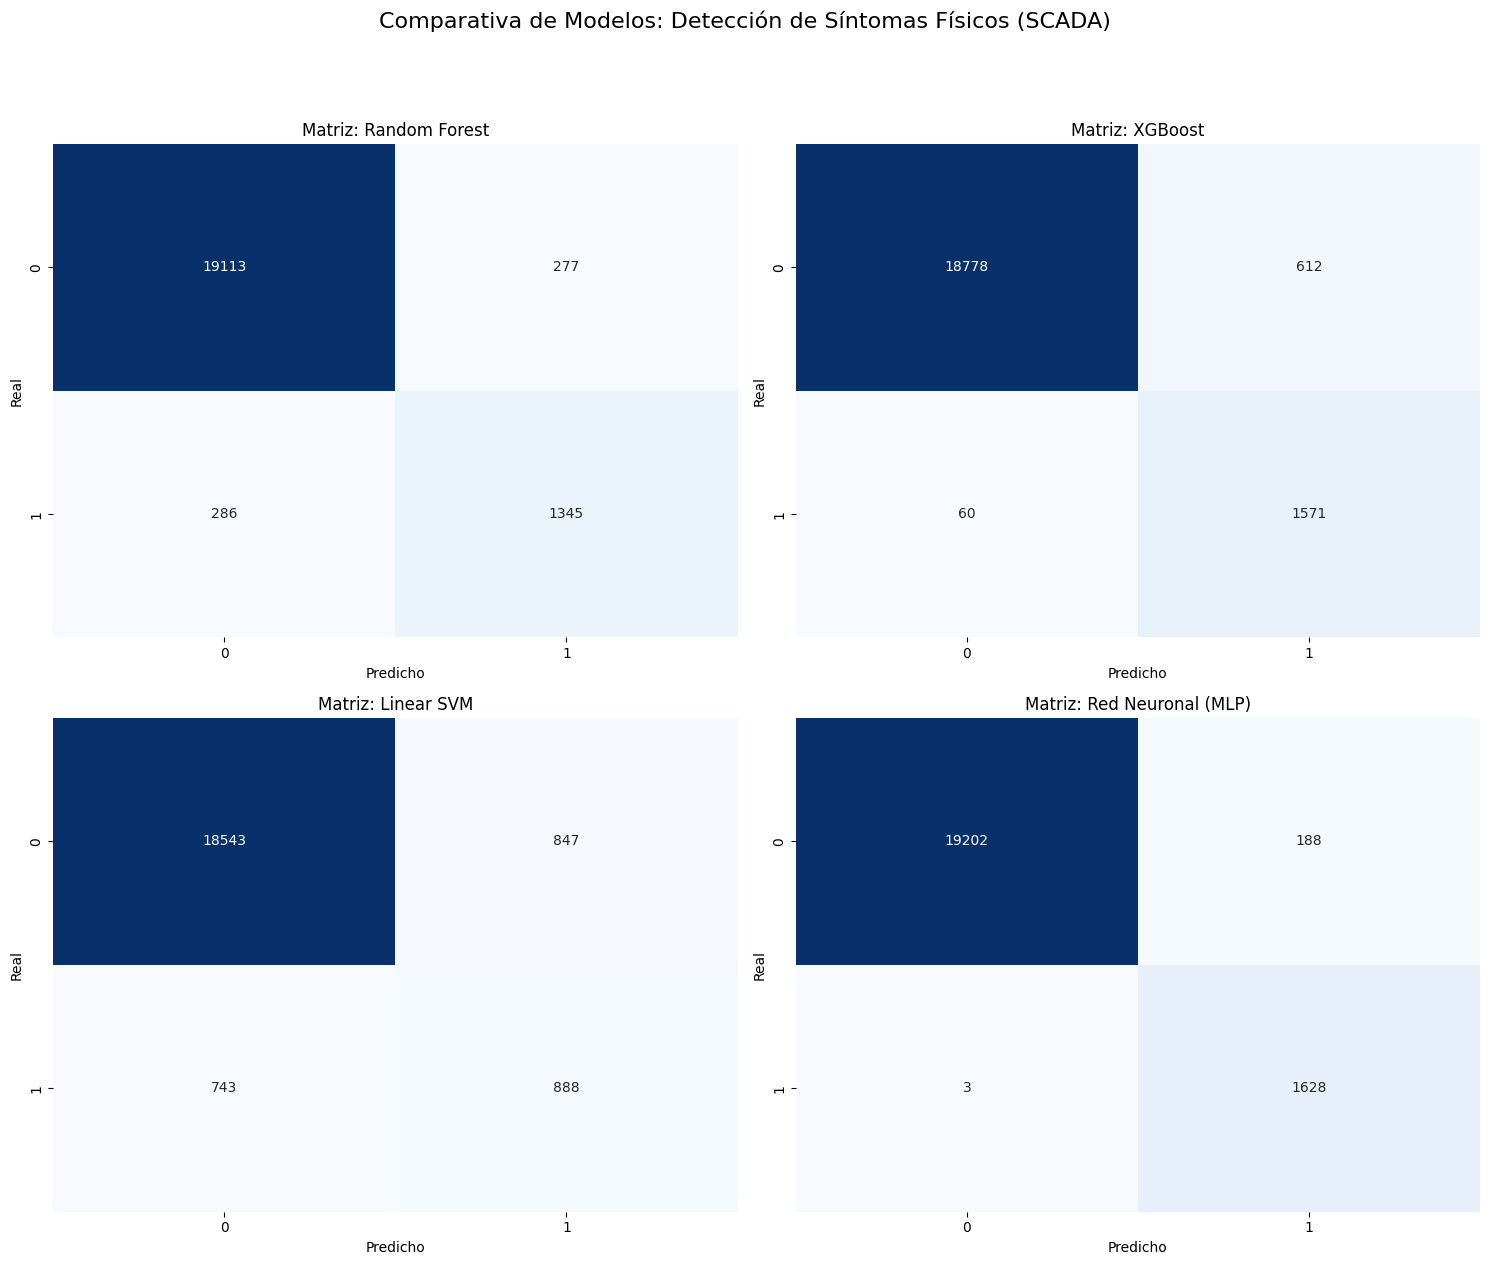

In [17]:
# --- Visualización de la Competencia ---
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Definición de la Función
def plot_confusion_en_eje(y_real, y_pred, titulo, ax_obj):
    """
    Dibuja la matriz de confusión en un eje específico del subplot.
    """
    cm = confusion_matrix(y_real, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_obj, cbar=False)
    ax_obj.set_title(f'Matriz: {titulo}')
    ax_obj.set_ylabel('Real')
    ax_obj.set_xlabel('Predicho')

# 2. Visualización de la Competencia
# --- Visualización de la Competencia (Target: SCADA) ---
fig, ax = plt.subplots(2, 2, figsize=(15, 12)) # Cambiado a 4 columnas

# APLANAMOS el array para acceder como ax_flat[0], [1], [2], [3]
ax_flat = ax.flatten()

plot_confusion_en_eje(y_test, pred_rf, "Random Forest", ax_flat[0])
plot_confusion_en_eje(y_test, pred_xgb, "XGBoost", ax_flat[1])
plot_confusion_en_eje(y_test, pred_svm, "Linear SVM", ax_flat[2])
plot_confusion_en_eje(y_test, pred_nn, "Red Neuronal (MLP)", ax_flat[3])

plt.suptitle('Comparativa de Modelos: Detección de Síntomas Físicos (SCADA)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()